## 📌 Logistic Regression: From Linear Prediction to Probability

### 1) Linear Regression vs Logistic Regression (GLM family)

In **linear regression**, we model the target as a linear combination of features:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p
$$

This produces a real-valued output:

$$
\hat{y} \in (-\infty, +\infty)
$$

which works well when the target variable \( y \) is **continuous**.

---

However, when \( y \) is **binary** (e.g. 0/1), a major problem appears:

- A linear model can predict values **outside** the interval \([0, 1]\)
- Such values cannot be interpreted as probabilities

➡️ Therefore, we need a transformation that maps real numbers to valid probabilities in \([0, 1]\).

**Logistic regression** solves this by modeling **odds** and **log-odds (logit)** instead of probabilities directly.

---

### 2) Odds and Log-Odds (Logit)

Let \( p \) be the probability of success.

#### Odds

Odds are defined as:

$$
\text{odds} = \frac{p}{1 - p}
$$

This compares the probability of success to the probability of failure.

Examples:

- If \( p = 0.8 \):

$$
\text{odds} = \frac{0.8}{0.2} = 4 \quad \text{(4 to 1)}
$$

- If \( p = 0.5 \):

$$
\text{odds} = 1 \quad \text{(equal chances)}
$$

- If \( p = 0.2 \):

$$
\text{odds} = \frac{0.2}{0.8} = 0.25 \quad \text{(1 to 4)}
$$

---

#### Log-Odds (Logit)

Taking the natural logarithm of the odds gives the **logit**:

$$
\text{logit}(p) = \log\left(\frac{p}{1 - p}\right)
$$

Key property:

- $( p \in (0, 1) )$
- $( \text{logit}(p) \in (-\infty, +\infty) )$

✅ This makes log-odds perfectly suited for linear modeling.

---

### 3) Logistic Regression as a Generalized Linear Model (GLM)

Instead of modeling \( p \) directly, logistic regression models the **log-odds** as a linear function:

$$
\log\left(\frac{p}{1 - p}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p
$$

The right-hand side is the familiar **linear predictor**, commonly denoted as:

$$
z = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p
$$

This allows us to apply linear regression concepts within the **GLM framework**.

---

### 4) From Log-Odds Back to Probability

Starting from the logit equation:

$$
\log\left(\frac{p}{1 - p}\right) = z
$$

Exponentiate both sides:

$$
\frac{p}{1 - p} = e^z
$$

Solve for \( p \):

$$
p = \frac{e^z}{1 + e^z}
$$

Or equivalently:

$$
p = \frac{1}{1 + e^{-z}}
$$

This function is known as the **sigmoid (logistic) function**.

---

📌 **Key takeaway**  
The sigmoid function always maps any real number $z \in (-\infty, +\infty)$ to a valid probability:

$$
p \in (0, 1)
$$

This is what makes logistic regression suitable for binary classification.


## 5) Loss Function: Log Loss (Cross-Entropy)

Logistic regression does **not** minimize squared error.

It minimizes **log loss**, derived from maximum likelihood estimation.

For one observation:

$$
\ell(y, \hat{p}) = - \left[ y \log(\hat{p}) + (1-y) \log(1-\hat{p}) \right]
$$

For $N$ samples:

$$
\mathcal{L} = - \frac{1}{N} \sum_{i=1}^{N} \left[y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i) \right]
$$

---

## Let's see a synthetic example of logistic regression with gradient descent as a solver. 
Note that gradient descent is not the default solver for logistic regression, instead it uses more advanced solvers, but let's understand the logic behind the model using gradient descent. 

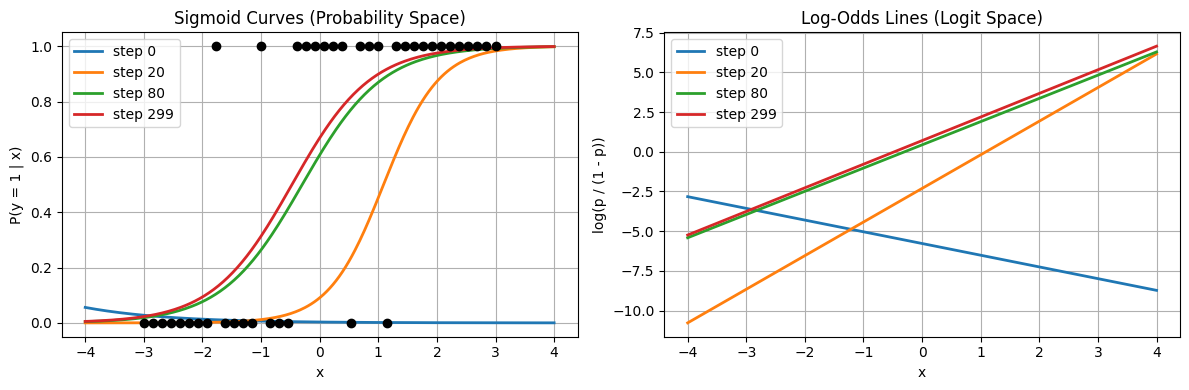

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Toy binary dataset
# ----------------------------
np.random.seed(0)

X = np.linspace(-3, 3, 40)
true_b0, true_b1 = -0.5, 1.5

p_true = 1 / (1 + np.exp(-(true_b0 + true_b1 * X)))
y = np.random.binomial(1, p_true)

# ----------------------------
# 2. Sigmoid
# ----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ----------------------------
# 3. Gradient ascent (slow on purpose)
# ----------------------------
b0, b1 = -6.0, -1.0      # very bad start
lr = 0.01               # SMALL learning rate
total_steps = 300
snapshots = [0, 20, 80, 299]

x_plot = np.linspace(-4, 4, 300)

plt.figure(figsize=(12, 4))

for step in range(total_steps):
    z = b0 + b1 * X
    p = sigmoid(z)

    # gradients of log-likelihood
    db0 = np.sum(y - p)
    db1 = np.sum((y - p) * X)

    # update
    b0 += lr * db0
    b1 += lr * db1

    if step in snapshots:
        z_plot = b0 + b1 * x_plot
        sigmoid_plot = sigmoid(z_plot)

        # ---- Left: probability space
        plt.subplot(1, 2, 1)
        plt.plot(x_plot, sigmoid_plot, linewidth=2,
                 label=f"step {step}")

        # ---- Right: log-odds space
        plt.subplot(1, 2, 2)
        plt.plot(x_plot, z_plot, linewidth=2,
                 label=f"step {step}")

# ----------------------------
# Final touches
# ----------------------------
plt.subplot(1, 2, 1)
plt.scatter(X, y, color="black", zorder=3)
plt.title("Sigmoid Curves (Probability Space)")
plt.xlabel("x")
plt.ylabel("P(y = 1 | x)")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title("Log-Odds Lines (Logit Space)")
plt.xlabel("x")
plt.ylabel("log(p / (1 - p))")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Let's see a real model example

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)
log_loss(y_test, y_proba)

/Users/zhanar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.06991550589372945

In [3]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9649122807017544

In [4]:
print(model.solver)

lbfgs


## Why This Happens

When you see the warning:
> `lbfgs failed to converge`

it means:
The optimizer stopped because it reached the maximum number of iterations(`max_iter=500`) **before fully converging**.

This **does NOT** mean your model is broken.  
It simply means the optimization process did not completely finish.

---

**These solvers are used for the Logistics Regression, by lbfgs being the default solver**
| Solver      | Type                      |
| ----------- | ------------------------- |
| `lbfgs`     | Quasi-Newton (2nd order)  |
| `newton-cg` | Newton method             |
| `liblinear` | Coordinate descent        |
| `saga`      | Stochastic gradient–based |


---
# Let's talk about solvers a little bit (MATH ALERT!🚨‼️🔔  )
# Part 1️⃣ Why Log Loss is Convex in Logistic Regression

## Setup

Binary logistic regression:

$$
p_i = \sigma(z_i) = \frac{1}{1 + e^{-z_i}}, \quad z_i = x_i^T \beta
$$

Log loss (negative log-likelihood):

$$
L(\beta) = -\sum_{i=1}^{n} \left[y_i \log p_i + (1-y_i)\log(1-p_i)\right]
$$

## Step 1: Rewrite the Loss

Using the identity:

$$
\log(1-\sigma(z)) = -\log(1+e^{z})
$$

Per-sample loss becomes:

$$
\ell_i(\beta) = \log(1+e^{x_i^T\beta}) - y_i x_i^T\beta
$$

Total loss:

$$
L(\beta)=\sum_{i=1}^{n}\left[\log(1+e^{x_i^T\beta}) - y_i x_i^T\beta\right]
$$

## Step 2: Convexity Check

Gradient:

$$
\nabla L(\beta)=\sum_{i=1}^{n} x_i\left(\sigma(x_i^T\beta)-y_i\right)
$$

Hessian:

$$
H=\sum_{i=1}^{n} x_i x_i^T \sigma(z_i)(1-\sigma(z_i))
$$

Key facts:

- $x_i x_i^T$ is positive semi-definite  
- $\sigma(z_i)(1-\sigma(z_i)) \ge 0$

Since the Hessian is a sum of positive semi-definite matrices:

$$
H \succeq 0
$$

Therefore, the loss is **convex**.

## Why This Matters

- One global minimum  
- No local minima  
- Stable optimization  
- Gradient-based methods converge (with proper step size)  

This is why logistic regression is mathematically elegant.

---

# Part 2️⃣ What LBFGS Does Mathematically

LBFGS = Limited-memory Broyden–Fletcher–Goldfarb–Shanno  
It is a **quasi-Newton method**.

## Gradient Descent

$$
\beta_{t+1} = \beta_t - \eta \nabla L(\beta_t)
$$

Uses only gradient.  
Slow, zig-zag behavior, sensitive to scaling.

## Newton’s Method

$$
\beta_{t+1} = \beta_t - H^{-1}\nabla L(\beta_t)
$$

Uses curvature (Hessian).  
Quadratic convergence near optimum.  
But computing $H^{-1}$ costs $O(d^3)$.

## What LBFGS Does

Instead of computing $H^{-1}$, LBFGS builds an approximation:

$$
B_t \approx H^{-1}
$$

Using update vectors:

$$
s_t = \beta_{t+1}-\beta_t
$$

$$
y_t = \nabla L_{t+1}-\nabla L_t
$$

Full BFGS stores a $d\times d$ matrix ($O(d^2)$ memory).  
LBFGS stores only the last $m$ updates ($O(md)$ memory).

Hence: **Limited-memory**.

## Intuition

- Gradient descent: move downhill  
- Newton: adjust for curvature  
- LBFGS: estimate curvature from recent history without computing the Hessian  

## Why LBFGS Works Well for Logistic Regression

- Loss is convex  
- Hessian is well-defined  
- Problem is smooth  
- Converges much faster than gradient descent  

That’s why `sklearn` uses it by default.

---

# Interview-Level Summary

**Why is logistic regression convex?**  
Because its Hessian is a sum of positive semi-definite matrices  
$$
x_i x_i^T \sigma(z_i)(1-\sigma(z_i))
$$
which guarantees convexity and a unique global minimum.

**What does LBFGS do?**  
It approximates the inverse Hessian using gradient differences, enabling second-order optimization without explicitly computing or storing the Hessian.


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=500)
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)
log_loss(y_test, y_proba)

0.060303879998519036

Effect of Feature Scaling

After applying StandardScaler, the convergence warning disappears.
This is because logistic regression is optimized using a gradient-based solver (LBFGS), which is sensitive to feature scaling.

Scaling improves the conditioning of the optimization problem and allows faster and more stable convergence.

In [6]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9824561403508771

**Scaling improves convergence efficiency, not predictive capacity (accuracy etc.).**

### How logistic regression behaves statistically and geometrically in real-world modeling.

# Regularization in Logistic Regression

## 🔹 Theory / Math

Logistic regression minimizes the **negative log-likelihood (log loss)**:

$$
L(\beta) = - \sum_{i=1}^{n} \left[ y_i \log p_i + (1-y_i) \log(1-p_i) \right]
$$

where

$$
p_i = \sigma(x_i^T \beta)
$$

---

### L2 Regularization (Ridge)

Adds a penalty on the size of coefficients:

$$
L_{\text{reg}}(\beta) = L(\beta) + \frac{\lambda}{2} \|\beta\|_2^2
= - \sum_{i=1}^{n} \left[ y_i \log p_i + (1-y_i) \log(1-p_i) \right] + \frac{\lambda}{2} \sum_{j=1}^{d} \beta_j^2
$$

- $\lambda$ = regularization strength (in `sklearn`: $C = 1/\lambda$)  
- Prevents overfitting by shrinking coefficients  
- Encourages a **smoother decision boundary**

---

### L1 Regularization (Lasso)

Adds a penalty on the sum of absolute coefficients:

$$
L_{\text{reg}}(\beta) = L(\beta) + \lambda \|\beta\|_1
= - \sum_{i=1}^{n} \left[ y_i \log p_i + (1-y_i) \log(1-p_i) \right] + \lambda \sum_{j=1}^{d} |\beta_j|
$$

- Produces **sparse coefficients** (feature selection)  
- Useful for **high-dimensional data**

---

**Key Takeaways:**

- L2: shrinks coefficients, stable for all features  
- L1: can zero out some coefficients → automatic feature selection  
- Regularization improves **generalization** and prevents **overfitting**


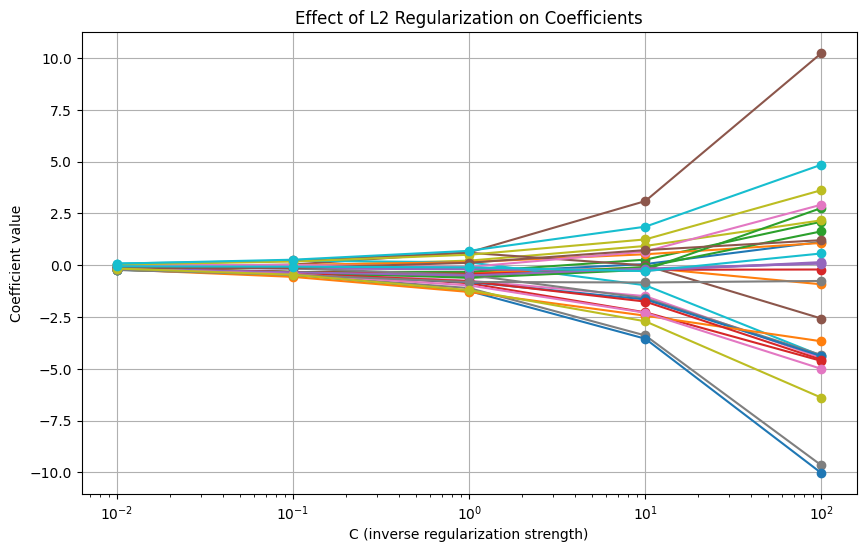

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import numpy as np

# Using same dataset as before
X = data.data
y = data.target

# Split dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit L2-regularized logistic regression with different C values
C_values = [0.01, 0.1, 1, 10, 100]
coefs = []

for C in C_values:
    model = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=500))
    model.fit(X_train, y_train)
    coefs.append(model.named_steps['logisticregression'].coef_[0])

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(C_values, coefs[:, i], marker='o', label=f'feature {i}')
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('Coefficient value')
plt.title('Effect of L2 Regularization on Coefficients')
plt.grid(True)
plt.show()


✅ Interpretation:

- Small C → strong regularization → coefficients shrink toward 0
- Large C → weak regularization → coefficients approach unregularized values

/Users/zhanar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/zhanar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/zhanar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/zhanar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


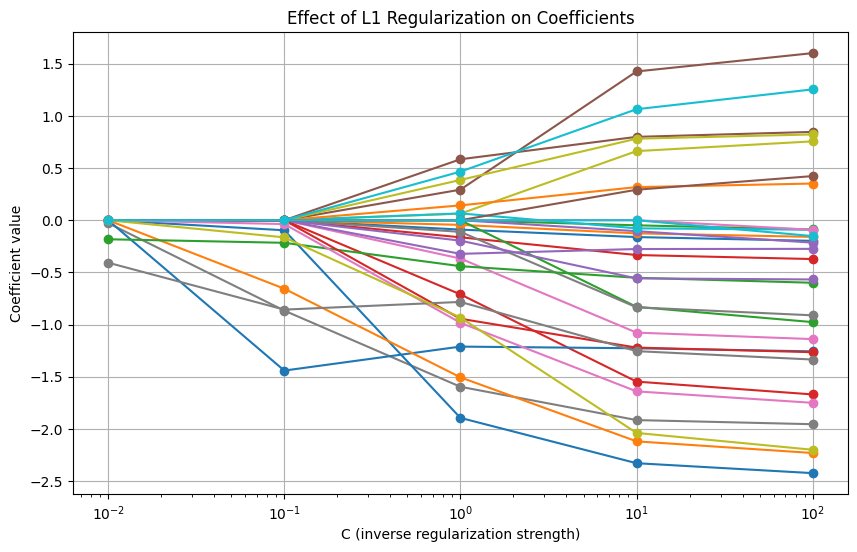

In [8]:
# Using the same breast cancer dataset
X = data.data
y = data.target

# Split dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit L1-regularized logistic regression with different C values
C_values = [0.01, 0.1, 1, 10, 100]
coefs = []

for C in C_values:
    model = make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', solver='saga', C=C, max_iter=500))
    model.fit(X_train, y_train)
    coefs.append(model.named_steps['logisticregression'].coef_[0])

coefs = np.array(coefs)

plt.figure(figsize=(10,6))
for i in range(coefs.shape[1]):
    plt.plot(C_values, coefs[:, i], marker='o', label=f'feature {i}')
plt.xscale('log')
plt.xlabel('C (inverse regularization strength)')
plt.ylabel('Coefficient value')
plt.title('Effect of L1 Regularization on Coefficients')
plt.grid(True)
plt.show()


You see: 
> ConvergenceWarning: The max_iter was reached which means the coef_ did not converge

# Why This Happens with L1 Regularization

- **Non-smoothness at 0:** L1 regularization introduces a kink at 0, making it harder for gradient-based solvers to converge quickly.  
- **Solver behavior:** The solver (e.g., `saga`) may stop at `max_iter=500` before fully reaching the optimal solution.

## Key Takeaways

- This warning is **normal for L1** with many features.  
- Increasing `max_iter` can help convergence, but this is also **educational**: it shows that **L1 is harder to optimize than L2**.  
- Strong L1 regularization may **zero out coefficients** even if the solver has not fully converged.  
- In practice, convergence warnings indicate that we should **monitor solver behavior and adjust iterations**.


In [9]:
# # Maybe try yourself the code for Logistic Regression with L1 regularization
# model = LogisticRegression(
#     penalty='l1',      # L1 regularization
#     solver='saga',     # saga supports L1
#     C=1.0,             # Regularization strength (C = 1/lambda)
#     max_iter=5000,     # Increase iterations to ensure convergence
#     random_state=42
# )

# 2️⃣ Geometry of Decision Boundary

## 🔹 Theory / Math

For logistic regression, the **decision boundary is linear**:

$$
p(y=1 \mid x) = \sigma(\beta_0 + \beta^T x) = 0.5
$$

This implies:

$$
\beta_0 + \beta^T x = 0
$$

- Defines a **hyperplane** in feature space  
- Coefficients $\beta$ determine the **slope and orientation** of the boundary  
- **Regularization** affects the steepness and orientation of the decision boundary


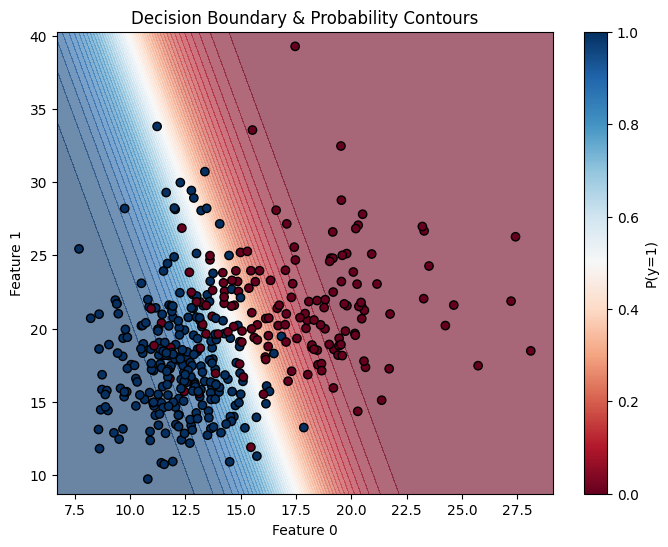

In [10]:
# Use two features for visualization
X_vis = X_train[:, :2]

model_vis = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=500))
model_vis.fit(X_vis, y_train)

# Grid for plotting
xx, yy = np.meshgrid(np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 200),
                     np.linspace(X_vis[:,1].min()-1, X_vis[:,1].max()+1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model_vis.predict_proba(grid)[:,1].reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs, levels=50, cmap="RdBu", alpha=0.6)
plt.scatter(X_vis[:,0], X_vis[:,1], c=y_train, cmap='RdBu', edgecolor='k')
plt.title("Decision Boundary & Probability Contours")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.colorbar(label="P(y=1)")
plt.show()


✅ Interpretation:

- Red → P(y=1) high, Blue → P(y=0) high
- Boundary = where P(y=1) = 0.5
- Shows linear separation

# 3️⃣ Evaluation Metrics
## 🔹 ROC & AUC

- ROC = Receiver Operating Characteristic
- Plots True Positive Rate vs False Positive Rate
- AUC = area under curve → measure of separability

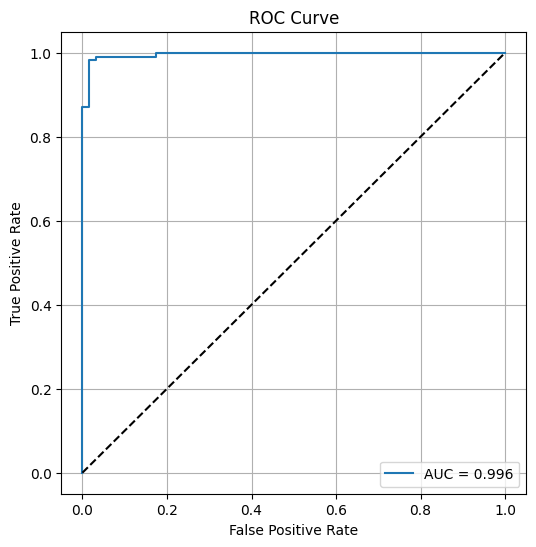

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)
plt.legend()
plt.show()


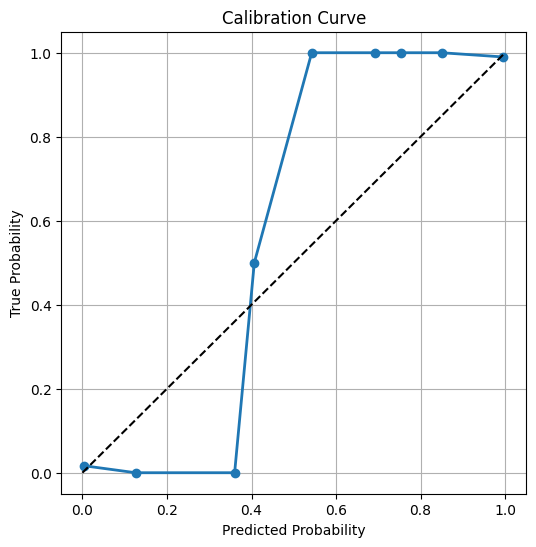

In [12]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve')
plt.grid(True)
plt.show()


✅ Interpretation:

- Points close to diagonal → well-calibrated probabilities
- Above → underconfident
- Below → overconfident

# Accuracy Paradox

## 🔹 Theory / Math

Accuracy is defined as:

$$
\text{Accuracy} = \frac{\text{\# correct predictions}}{\text{total \# samples}}
$$

**Problem:** For **imbalanced datasets**, accuracy can be misleading.

**Example:**

- Suppose 99% of samples belong to class 0  
- Model predicts 0 **always**  
- Accuracy = 99%  

Yet, the model **fails completely on the minority class**.  

This phenomenon is called the **accuracy paradox**.


In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Simulate imbalanced dataset
y_true = np.array([0]*90 + [1]*10)  # 100 samples, 90 zeros, 10 ones
y_pred = np.zeros_like(y_true)      # Model predicts all 0

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.2f}")

print("\nClassification Report:")
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, zero_division=0))


Accuracy: 0.90

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        90
           1       0.00      0.00      0.00        10

    accuracy                           0.90       100
   macro avg       0.45      0.50      0.47       100
weighted avg       0.81      0.90      0.85       100



**Solution:** use metrics like precision, recall, F1-score, ROC-AUC, log loss. Especially important in medical diagnosis, fraud detection, anomaly detection.

# Limitations & When to Use Other Models
## 🔹 Limitations

- Linear decision boundary only → cannot capture complex non-linear patterns
- Sensitive to outliers in features
- Cannot handle highly correlated features well
- May fail with large feature spaces → use regularization
- Assumes log-odds linear in features

| Situation                         | Alternative Model                        | Why                       |
| --------------------------------- | ---------------------------------------- | ------------------------- |
| Non-linear separation             | Decision Trees / Random Forest           | Flexible boundaries       |
| High-dimensional sparse data      | L1-regularized Logistic                  | Feature selection         |
| Complex patterns                  | Neural Networks                          | Capture non-linearities   |
| Probability calibration important | Gradient Boosting + CalibratedClassifier | Better probability output |
